In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Dropout
from tensorflow.keras.models import Model
import os

In [33]:
CSV_PATH = r'C:\Users\LENOVO\Desktop\Structural_Damage_Detection\archive\infrastructure_defect_dataset.csv'
POS_DIR = r'C:\Users\LENOVO\Desktop\Structural_Damage_Detection\archive\Cracks\Positive'

df = pd.read_csv(CSV_PATH)

In [37]:
df['Image_Name'] = [f"{i:05d}.jpg" for i in range(1, len(df) + 1)]

image_paths = [os.path.join(POS_DIR, ad) for ad in df['Image_Name']]

In [36]:
labels_defect = LabelBinarizer().fit_transform(df['Target_Defect_Class'].astype(str))
labels_severity = LabelBinarizer().fit_transform(df['Severity_Level'].astype(str))
labels_width = df['Defect_Width_mm'].fillna(0.0).astype(np.float32).values

In [24]:
print("Encoding categorical labels...")
labels_defect = LabelBinarizer().fit_transform(df['Target_Defect_Class'].astype(str))
labels_severity = LabelBinarizer().fit_transform(df['Severity_Level'].astype(str))
labels_width = df['Defect_Width_mm'].fillna(0.0).astype(np.float32).values


Encoding categorical labels...


In [38]:
print("Splitting data into Train and Validation...")
(train_paths, val_paths, 
 train_def, val_def, 
 train_sev, val_sev, 
 train_wid, val_wid) = train_test_split(
    image_paths, labels_defect, labels_severity, labels_width, 
    test_size=0.2, random_state=42
)

Splitting data into Train and Validation...


In [39]:
@tf.function
def process_data(img_path, lbl_defect, lbl_severity, lbl_width):
    img = tf.io.read_file(img_path)
    # Burası da önemli: decode_jpeg aslında .jpg dosyalarını da çözer
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224]) / 255.0
    
    # Keras'ın kafası karışmasın diye Tuple kullanıyoruz
    targets = (lbl_defect, lbl_severity, lbl_width)
    return img, targets

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_def, train_sev, train_wid))
train_dataset = train_dataset.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_def, val_sev, val_wid))
val_dataset = val_dataset.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [45]:
print("Building Multi-Task ResNet50 Model...")
input_tensor = Input(shape=(224, 224, 3), name='image_input')
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
shared_features = GlobalAveragePooling2D(name='shared_features')(x)
shared_features = Dropout(0.3)(shared_features)

out_defect = Dense(labels_defect.shape[1], activation='softmax', name='defect_class')(shared_features)
out_severity = Dense(labels_severity.shape[1], activation='softmax', name='severity_level')(shared_features)
out_width = Dense(1, activation='relu', name='defect_width')(shared_features)

multi_task_model = Model(inputs=input_tensor, outputs=[out_defect, out_severity, out_width])

multi_task_model.compile(
    optimizer='adam',
    loss=['categorical_crossentropy', 'categorical_crossentropy', 'mse'],
    loss_weights=[1.0, 1.0, 0.005],
    metrics=[['accuracy'], ['accuracy'], ['mae']]
)

Building Multi-Task ResNet50 Model...


In [46]:
EPOCHS = 5
print(" Training starting! Please wait...")

history = multi_task_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

 Training starting! Please wait...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - defect_class_accuracy: 0.2338 - defect_class_loss: 1.7153 - defect_width_loss: 738.2125 - defect_width_mae: 23.0769 - loss: 6.5781 - severity_level_accuracy: 0.3750 - severity_level_loss: 1.1717 - val_defect_class_accuracy: 0.2725 - val_defect_class_loss: 1.5875 - val_defect_width_loss: 513.5135 - val_defect_width_mae: 18.7721 - val_loss: 5.2671 - val_severity_level_accuracy: 0.3500 - val_severity_level_loss: 1.1073
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - defect_class_accuracy: 0.2537 - defect_class_loss: 1.6370 - defect_width_loss: 364.6557 - defect_width_mae: 15.6479 - loss: 4.6037 - severity_level_accuracy: 0.3587 - severity_level_loss: 1.1434 - val_defect_class_accuracy: 0.2725 - val_defect_class_loss: 1.5902 - val_defect_width_loss: 266.4371 - val_defect_width_mae: 13.6694 - val_loss: 3.9801 - val_severity_level_accuracy: 0.4400 - val_severity_level_loss: 1.0550
Epoch 3/5
50/50 ━━━━━━━

In [ ]:
import numpy as np
import tensorflow as tf


URL = "https://media.istockphoto.com/id/171151393/tr/foto%C4%9Fraf/a-big-crack-on-an-old-rotten-wall.jpg?s=2048x2048&w=is&k=20&c=TrXrdh-Xu9GvD0Oc5hNbgTIgajtVSy5w-F5uPXmPkps="
resim_yolu = tf.keras.utils.get_file(origin=URL)

img = tf.keras.utils.load_img(resim_yolu, target_size=(224, 224))
img_array = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, axis=0)

tahminler = multi_task_model.predict(img_array)

print("\n--- TEST SONUÇLARI ---")
print(f"Hasar Türü (Grup No) / Damage Type (Group No.)    : {np.argmax(tahminler[0])}")
print(f"Şiddet Seviyesi (Grup No) / Severity Level (Group No.): {np.argmax(tahminler[1])}")
print(f"Tahmini Genişlik    / Estimated Width     : {tahminler[2][0][0]:.2f} mm")
print("----------------------\n")



🔍 Kaydetmeden Önce Hızlı Test Yapılıyor...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- TEST SONUÇLARI ---
Hasar Türü (Grup No)     : 1
Şiddet Seviyesi (Grup No): 1
Tahmini Genişlik         : 24.95 mm
----------------------



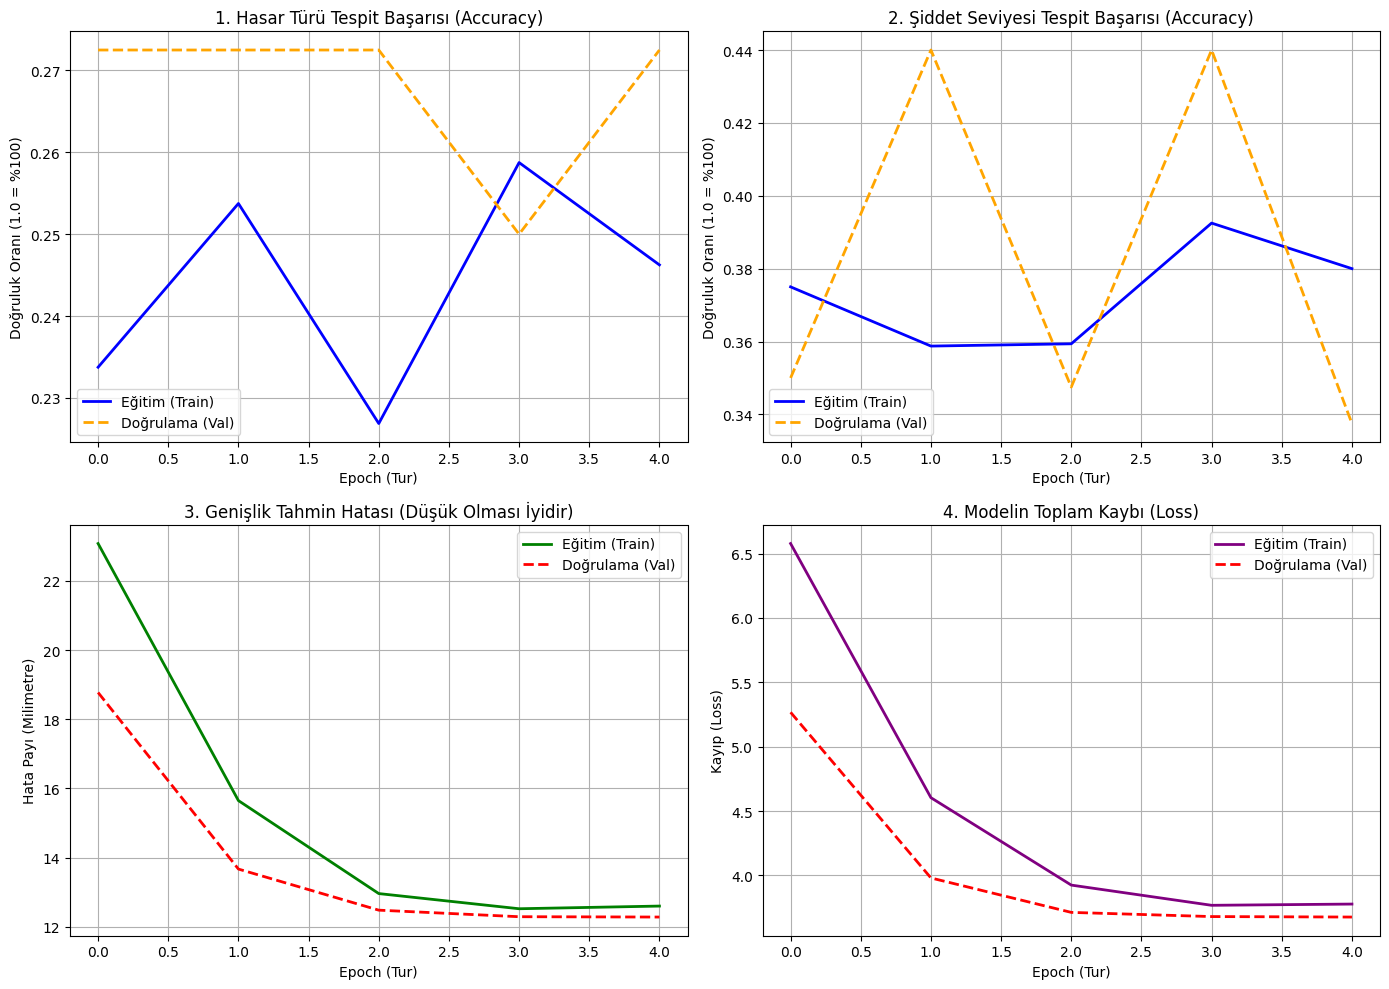

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['defect_class_accuracy'], label='Eğitim (Train)', color='blue', linewidth=2)
plt.plot(history.history['val_defect_class_accuracy'], label='Doğrulama (Val)', color='orange', linestyle='dashed', linewidth=2)
plt.title('1. Hasar Türü Tespit Başarısı (Accuracy / Damage Type Detection Success)')
plt.ylabel('Doğruluk Oranı /Accuracy Rate (1.0 = %100)')
plt.xlabel('Epoch (Tur)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history.history['severity_level_accuracy'], label='Eğitim (Train)', color='blue', linewidth=2)
plt.plot(history.history['val_severity_level_accuracy'], label='Doğrulama (Val)', color='orange', linestyle='dashed', linewidth=2)
plt.title('2. Şiddet Seviyesi Tespit Başarısı (Accuracy / Severity Level Detection Success)')
plt.ylabel('Doğruluk Oranı / Accuracy Rate(1.0 = %100)')
plt.xlabel('Epoch (Tur)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(history.history['defect_width_mae'], label='Eğitim (Train)', color='green', linewidth=2)
plt.plot(history.history['val_defect_width_mae'], label='Doğrulama (Val)', color='red', linestyle='dashed', linewidth=2)
plt.title('3. Genişlik Tahmin Hatası (Width Estimation Error)')
plt.ylabel('Hata Payı / tolerance (Milimetre)')
plt.xlabel('Epoch (Tur)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(history.history['loss'], label='Eğitim (Train)', color='purple', linewidth=2)
plt.plot(history.history['val_loss'], label='Doğrulama (Val)', color='red', linestyle='dashed', linewidth=2)
plt.title('4. Modelin Toplam Kaybı (Loss)')
plt.ylabel('Kayıp (Loss)')
plt.xlabel('Epoch (Tur)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
multi_task_model.save('multi_task_model.keras')
